## Dataset Inspection

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("AppReview.csv")

# basic view
df.head()

,appID,reviewerName,reviewText,reviewerRating,reviewDate,textAnalytics
0,3,Eric Hansen,Love it! WELL worth the money for the full ver...,1.0,2017/07/07 00:00:00,NaN
1,3,Jacob N.,There's an awful bug that doesn't allow you to...,0.4,2017/08/29 00:00:00,NaN
2,3,Higgins Family,Would be 5 stars except for the bugs.... For e...,0.8,2017/10/02 00:00:00,NaN
3,3,Rajko Dikmann,Worked perfect until a few weeks ago. Then bro...,0.4,2017/09/28 00:00:00,NaN
4,3,Sergei Garcia,Hands down the best browser on the play store!...,1.0,2017/07/09 00:00:00,NaN


In [3]:
df.shape

(111143, 6)

In [4]:
df.columns

Index(['appID', 'reviewerName', 'reviewText', 'reviewerRating', 'reviewDate',
       'textAnalytics'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111143 entries, 0 to 111142
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   appID           111143 non-null  int64  
 1   reviewerName    105840 non-null  object 
 2   reviewText      111143 non-null  object 
 3   reviewerRating  111143 non-null  float64
 4   reviewDate      111143 non-null  object 
 5   textAnalytics   487 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 5.1+ MB


In [10]:
# check unique values 
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].nunique())


Column: appID
492

Column: reviewerName
79372

Column: reviewText
100936

Column: reviewerRating
6

Column: reviewDate
6104

Column: textAnalytics
48


In [11]:
# check null values for each column 
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].isnull().sum())


Column: appID
0

Column: reviewerName
5303

Column: reviewText
0

Column: reviewerRating
0

Column: reviewDate
0

Column: textAnalytics
110656


In [12]:
# starting from the first column, basic analysis and small cleaning if needed
# appID
# Check duplicate reviews
df.duplicated().sum()

160

In [13]:
# create new column to count reviewText length for each observation
df['review_length'] = df['reviewText'].astype(str).apply(len)

df['review_length'].describe()

count    111143.000000
mean        113.990238
std         110.892098
min          13.000000
25%          40.000000
50%          80.000000
75%         149.000000
max        2501.000000
Name: review_length, dtype: float64

In [14]:
# check reviewText
df['reviewText'].head(5)

0    Love it! WELL worth the money for the full ver...
1    There's an awful bug that doesn't allow you to...
2    Would be 5 stars except for the bugs.... For e...
3    Worked perfect until a few weeks ago. Then bro...
4    Hands down the best browser on the play store!...
Name: reviewText, dtype: object

In [19]:
# analyze target variable
df['reviewerRating'].describe()

count    111143.000000
mean          0.830291
std           0.260836
min           0.000000
25%           0.800000
50%           1.000000
75%           1.000000
max           1.000000
Name: reviewerRating, dtype: float64

In [20]:
df['reviewerRating'].value_counts().sort_index()

reviewerRating
0.0       71
0.2    10296
0.4     5244
0.6     9160
0.8    18719
1.0    67653
Name: count, dtype: int64

<Axes: >

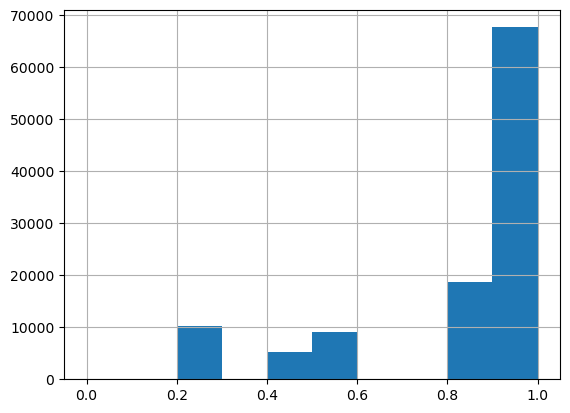

In [24]:
df['reviewerRating'].hist(bins=10)